# Anomaly detection with PatchCore

### Setup

In [7]:
import cv2
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
import numpy as np
import faiss
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Model + Feature Extraction

In [2]:
# Pretrained model
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-2])  # Remove classifier
model.eval().to(device)

/home/ids/nnavarro-24/anaconda3/envs/deepl/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ids/nnavarro-24/anaconda3/envs/deepl/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [3]:
# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Thermal to RGB
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet stats
                         [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

### Build Feature Bank (Core Set)

In [4]:
def extract_features(dataloader):
    features = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            feat = model(x)
            feat = feat.view(feat.size(0), feat.size(1), -1)  # B, C, H*W
            feat = feat.permute(0, 2, 1)  # B, N_patches, C
            features.append(feat.cpu())
    return torch.cat(features, dim=0).reshape(-1, 512).numpy()  # All patches

In [5]:
class AugmentedImageFolder(Dataset):
    def __init__(self, root, transform):
        self.dataset = ImageFolder(root, transform=None)  # defer transform
        self.transform = transform
        self.hflip = transforms.RandomHorizontalFlip(p=1.0)

    def __len__(self):
        return 2 * len(self.dataset)

    def __getitem__(self, idx):
        original_idx = idx % len(self.dataset)
        image, label = self.dataset[original_idx]

        if idx < len(self.dataset):
            image = self.transform(image)  # Original
        else:
            image = self.hflip(image)
            image = self.transform(image)  # Flipped

        return image, label

In [6]:
# IMPROVEMENT 1: Enhanced thermal image preprocessing
def enhance_thermal_image(img):
    """Apply contrast enhancement specifically for thermal images"""
    # Convert PIL to numpy if needed
    if isinstance(img, Image.Image):
        img_np = np.array(img)
    else:
        img_np = img
    
    # If it's color image, convert to grayscale
    if len(img_np.shape) == 3 and img_np.shape[2] == 3:
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_np
        
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)
    
    # Return as PIL Image
    return Image.fromarray(img_clahe)

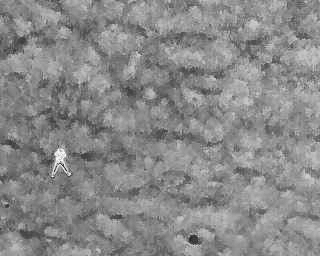

In [16]:
from PIL import Image

# get PIL image
def get_image(path):
    img = Image.open(path).convert('RGB')
    img = enhance_thermal_image(img)
    return img

img_path = 'data/test/abnormal/DJI_M300_H20t_0006.jpg'
img = get_image(img_path)
img

In [6]:
train_dataset = AugmentedImageFolder('data/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [7]:
feature_bank = extract_features(train_loader)

# # Optional: sample coreset (e.g., randomly keep 10%)
# np.random.shuffle(feature_bank)
# coreset = feature_bank[:int(len(feature_bank) * 0.1)]
coreset = feature_bank

In [8]:
# Build Faiss index
index = faiss.IndexFlatL2(coreset.shape[1])
index.add(coreset)

### Evaluate on test images

In [9]:
from PIL import Image
import os

def score_image(img_path):
    x = transform(Image.open(img_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model(x)
        feat = feat.view(feat.size(0), feat.size(1), -1).permute(0, 2, 1)
        patches = feat[0].cpu().numpy()
    D, _ = index.search(patches, k=1)
    return np.max(D)  # Highest patch distance = anomaly score

# Run test
test_paths = []
labels = []  # 0: normal, 1: abnormal
for label, subdir in enumerate(['normal', 'abnormal']):
    for img in os.listdir(f'data/test/{subdir}'):
        test_paths.append(f'data/test/{subdir}/{img}')
        labels.append(label)

scores = [score_image(p) for p in test_paths]

#### Metrics

AUROC: 0.7988888888888889


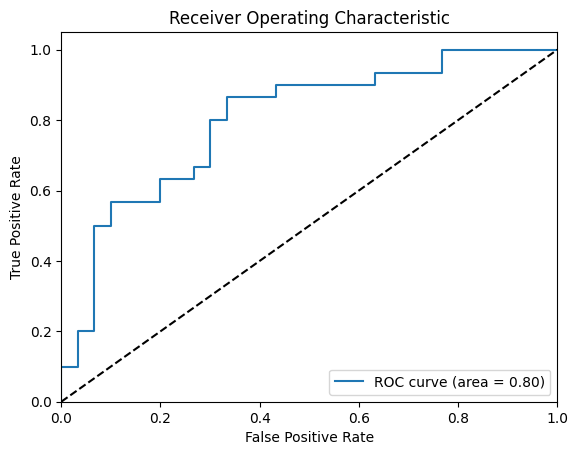

In [10]:
from sklearn.metrics import roc_auc_score
print("AUROC:", roc_auc_score(labels, scores))

# plot ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(labels, scores)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc_score(labels, scores))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


### Visualization

(49, 1)


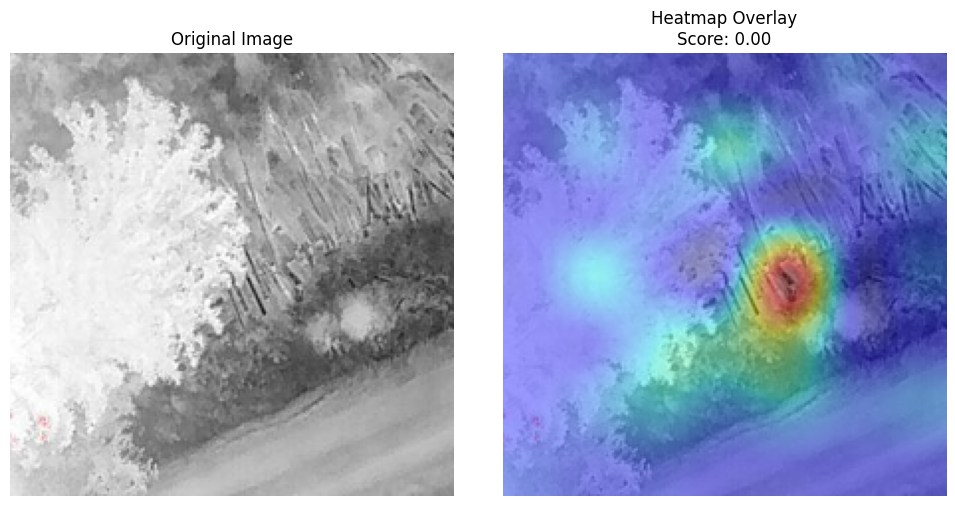

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
import numpy as np

def show_image_with_heatmap(img_path, model, transform, index, device):
    img = Image.open(img_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)

    # Extract features and compute distance map
    with torch.no_grad():
        feat = model(x)
        feat = feat.view(feat.size(0), feat.size(1), -1).permute(0, 2, 1)
        patches = feat[0].cpu().numpy()
    D, _ = index.search(patches, k=1)
    score = np.max(D)
    heatmap = D.reshape(7, 7)  # adjust based on model output
    heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0)
    heatmap_resized = F.interpolate(heatmap_tensor, size=(224, 224), mode='bicubic', align_corners=False)
    heatmap = heatmap_resized.squeeze().numpy()

    # Normalize heatmap for better visualization
    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    # Prepare the original image
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized)

    # Apply colormap to heatmap
    cmap = plt.get_cmap('jet')
    heatmap_colored = cmap(heatmap_norm)
    heatmap_overlay = (heatmap_colored[..., :3] * 255).astype(np.uint8)

    # Superimpose heatmap
    overlayed = (0.6 * img_array + 0.4 * heatmap_overlay).astype(np.uint8)

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_array)
    axs[0].set_title('Original Image')
    axs[0].axis('off')

    axs[1].imshow(overlayed)
    axs[1].set_title(f'Heatmap Overlay\nScore: {score:.2f}')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

# Example call:
show_image_with_heatmap('data/train/normal/DJI_M300_H20t_0019.jpg', model, transform, index, device)